In [1]:
#get necessary libraries
!pip install "nilearn>=0.9.0"
!pip install brainspace
!pip install panel
!pip list

Package                       Version
----------------------------- ---------
absl-py                       2.1.0
aiobotocore                   2.5.0
aiofiles                      22.1.0
aiohttp                       3.8.3
aioitertools                  0.7.1
aiosignal                     1.2.0
aiosqlite                     0.18.0
alabaster                     0.7.12
altair                        5.2.0
anaconda-anon-usage           0.4.4
anaconda-catalogs             0.2.0
anaconda-client               1.12.0
anaconda-cloud-auth           0.4.1
anaconda-navigator            2.5.4
anaconda-project              0.11.1
annotated-types               0.6.0
anyio                         3.5.0
appdirs                       1.4.4
applaunchservices             0.3.0
appnope                       0.1.2
appscript                     1.1.2
argon2-cffi                   21.3.0
argon2-cffi-bindings          21.2.0
arrow                         1.2.3
astroid                       2.14.2
astropy       

In [2]:
# if you want to get data into BIDS
#docker run -ti --rm \
 # -v <local_BIDS_data_dir>:/data:ro \
  #-v <local_output_dir>:/out poldracklab/fmriprep:latest \
  #--output-spaces fsaverage5 \
  #--fs-license-file license.txt \
  #/data /out participant

In [3]:
# download the packages
from brainspace.datasets import load_conte69
from brainspace.datasets import load_group_fc, load_parcellation
import numpy as np
import pandas as pd

import nibabel as nib
from nilearn import datasets
from brainspace.utils.parcellation import reduce_by_labels
from nilearn.connectome import ConnectivityMeasure

from brainspace.datasets import load_fsa5
from brainspace.plotting import plot_hemispheres
from brainspace.utils.parcellation import map_to_labels
from brainspace.gradient import GradientMaps

In [4]:
import pandas as pd
from brainspace.utils.parcellation import reduce_by_labels

parcellation_img = nib.load('01_study_specific_atlas_relabel.nii')
parcellation_data = parcellation_img.get_fdata()
print(parcellation_data.shape)

df = pd.read_csv('rois_labels.txt', header=None, delimiter='\s+')
print(df)
labels = df[1].to_numpy()
print(labels.shape)

(96, 96, 25)
       0                          1
0      1              Acumbens_left
1      2                   AID_left
2      3                   AIP_left
3      4                   AIV_left
4      5              Amygdala_left
..   ...                        ...
119  120                  SaP_right
120  121  Superior_Colliculus_right
121  122           Thalamus_A_right
122  123           Thalamus_P_right
123  124               VP_mfb_right

[124 rows x 2 columns]
(124,)


In [5]:
# CIMT Data - 07d
import os
folder_path = '07d'

# List to store dataframes
dfs_SHM_07d = []
dfs_CCI_07d = []

# Loop through files in the folder
for file_name in os.listdir(folder_path):
    if 'SHM' in file_name and file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)
        dfs_SHM_07d.append(df)
    elif 'CCI' in file_name and file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)
        dfs_CCI_07d.append(df)

mean_df_SHM_07d = pd.concat(dfs_SHM_07d).groupby(level=0).mean()
mean_df_CCI_07d = pd.concat(dfs_CCI_07d).groupby(level=0).mean()

# print(mean_df_SHM_07d)
# print(mean_df_CCI_07d)

mean_SHM_ts_07d = (mean_df_SHM_07d.T).values
mean_CCI_ts_07d = (mean_df_CCI_07d.T).values

# confound regression here

print(mean_SHM_ts_07d.shape)
seed_ts_SHM_07d = reduce_by_labels(mean_SHM_ts_07d, labels, axis=1, red_op='mean')
seed_ts_CCI_07d = reduce_by_labels(mean_CCI_ts_07d, labels, axis=1, red_op='mean')
print(seed_ts_SHM_07d)
print(seed_ts_SHM_07d.shape)

(124, 250)
[[ 99.92181684  99.90839587  99.88138594 ... 100.25909375 100.27206947
  100.29083287]
 [ 99.16211783  99.11628746  99.05990436 ...  99.32570603  99.40939758
   99.46570304]
 [100.17108324 100.1524257  100.11131413 ... 100.06276486 100.02146871
   99.93910036]
 ...
 [ 99.85720341  99.83991659  99.8424522  ...  99.76382645  99.71458362
   99.70155313]
 [ 99.71995223  99.73209601  99.74619068 ...  99.53742818  99.47018338
   99.42409966]
 [ 99.73204093  99.73341098  99.7365869  ...  99.71477449  99.70827152
   99.70803491]]
(124, 250)


In [6]:
# CIMT Data - 21d
folder_path = '21d'

# List to store dataframes
dfs_SHM_21d = []
dfs_CCI_21d = []

# Loop through files in the folder
for file_name in os.listdir(folder_path):
    if 'SHM' in file_name and file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)
        dfs_SHM_21d.append(df)
    elif 'CCI' in file_name and file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)
        dfs_CCI_21d.append(df)

mean_df_SHM_21d = pd.concat(dfs_SHM_21d).groupby(level=0).mean()
mean_df_CCI_21d = pd.concat(dfs_CCI_21d).groupby(level=0).mean()

# print(mean_df_SHM_21d)
# print(mean_df_CCI_21d)

mean_SHM_ts_21d = (mean_df_SHM_21d.T).values
mean_CCI_ts_21d = (mean_df_CCI_21d.T).values

# confound regression here

print(mean_SHM_ts_21d.shape)
seed_ts_SHM_21d = reduce_by_labels(mean_SHM_ts_21d, labels, axis=1, red_op='mean')
seed_ts_CCI_21d = reduce_by_labels(mean_CCI_ts_21d, labels, axis=1, red_op='mean')
print(seed_ts_SHM_21d)
print(seed_ts_SHM_21d.shape)

(124, 250)
[[ 99.95284777  99.92030542  99.90094983 ... 100.05673773 100.08233626
  100.09908175]
 [ 98.98877029  99.00511476  99.03873653 ...  99.16956366  99.23825831
   99.28887759]
 [ 99.99044442 100.01495788 100.070053   ...  99.99061521  99.97897422
   99.99406867]
 ...
 [100.04510667  99.98106164  99.90738517 ... 100.1572025  100.13204011
  100.13787783]
 [ 99.72399275  99.80584955  99.86570654 ...  99.88881231  99.88278719
   99.85291302]
 [ 99.74557099  99.73827189  99.74621886 ...  99.92072675  99.91619799
   99.9071864 ]]
(124, 250)


In [7]:
# CIMT Data - 49d
folder_path = '49d'

# List to store dataframes
dfs_SHM_49d = []
dfs_CCI_49d = []

# Loop through files in the folder
for file_name in os.listdir(folder_path):
    if 'SHM' in file_name and file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)
        dfs_SHM_49d.append(df)
    elif 'CCI' in file_name and file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)
        dfs_CCI_49d.append(df)

mean_df_SHM_49d = pd.concat(dfs_SHM_49d).groupby(level=0).mean()
mean_df_CCI_49d = pd.concat(dfs_CCI_49d).groupby(level=0).mean()

# print(mean_df_SHM_49d)
# print(mean_df_CCI_49d)

mean_SHM_ts_49d = (mean_df_SHM_49d.T).values
mean_CCI_ts_49d = (mean_df_CCI_49d.T).values

# confound regression here

print(mean_SHM_ts_49d.shape)
seed_ts_SHM_49d = reduce_by_labels(mean_SHM_ts_49d, labels, axis=1, red_op='mean')
seed_ts_CCI_49d = reduce_by_labels(mean_CCI_ts_49d, labels, axis=1, red_op='mean')
print(seed_ts_SHM_49d)
print(seed_ts_SHM_49d.shape)

(124, 250)
[[100.19999155 100.169199   100.13860871 ... 100.09126724 100.18743392
  100.26612621]
 [ 99.49115418  99.47918874  99.47217528 ...  99.52491142  99.51964229
   99.50861472]
 [ 99.69395447  99.74012987  99.78824594 ...  99.65524064  99.67824277
   99.72406917]
 ...
 [ 99.91796435  99.85494958  99.82259787 ...  99.9361458   99.97917094
  100.02522812]
 [ 99.85073388  99.78955597  99.71500941 ...  99.65955854  99.70279212
   99.73128446]
 [ 99.74861274  99.72185966  99.69401417 ...  99.86372499  99.92234527
   99.9540963 ]]
(124, 250)


[  0   1   2   3   4   5   6   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  26  27  28  29  30  31  34  35  36  37  38  39
  40  41  42  43  44  45  46  47  48  50  51  52  53  54  55  56  57  58
  59  60  62  64  66  67  70  71  72  73  74  76  77  78  79  80  81  83
  84  87  88  91  92  94  95  96  97  98 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 116 117 118 119 120 121]
(103, 103)
[  0   1   2   3   4   5   7  13  14  19  20  22  23  24  29  31  34  35
  36  38  39  40  42  43  44  45  46  48  50  51  52  53  54  55  56  57
  58  63  64  66  70  71  73  77  79  81  87  88  89  90  91  92  94  95
  98 100 101 102 103 105 107 109 111 117 118 119]
(66, 66)
[  0   1   2   3   4   5   6   7   8  10  11  12  13  14  16  17  18  19
  20  21  22  23  24  26  27  29  30  31  34  35  36  37  39  40  41  42
  43  44  45  46  47  48  50  51  52  53  54  55  56  57  58  59  60  61
  62  63  64  66  67  70  72  74  75  76  77  78  79  80  81  83  84  87


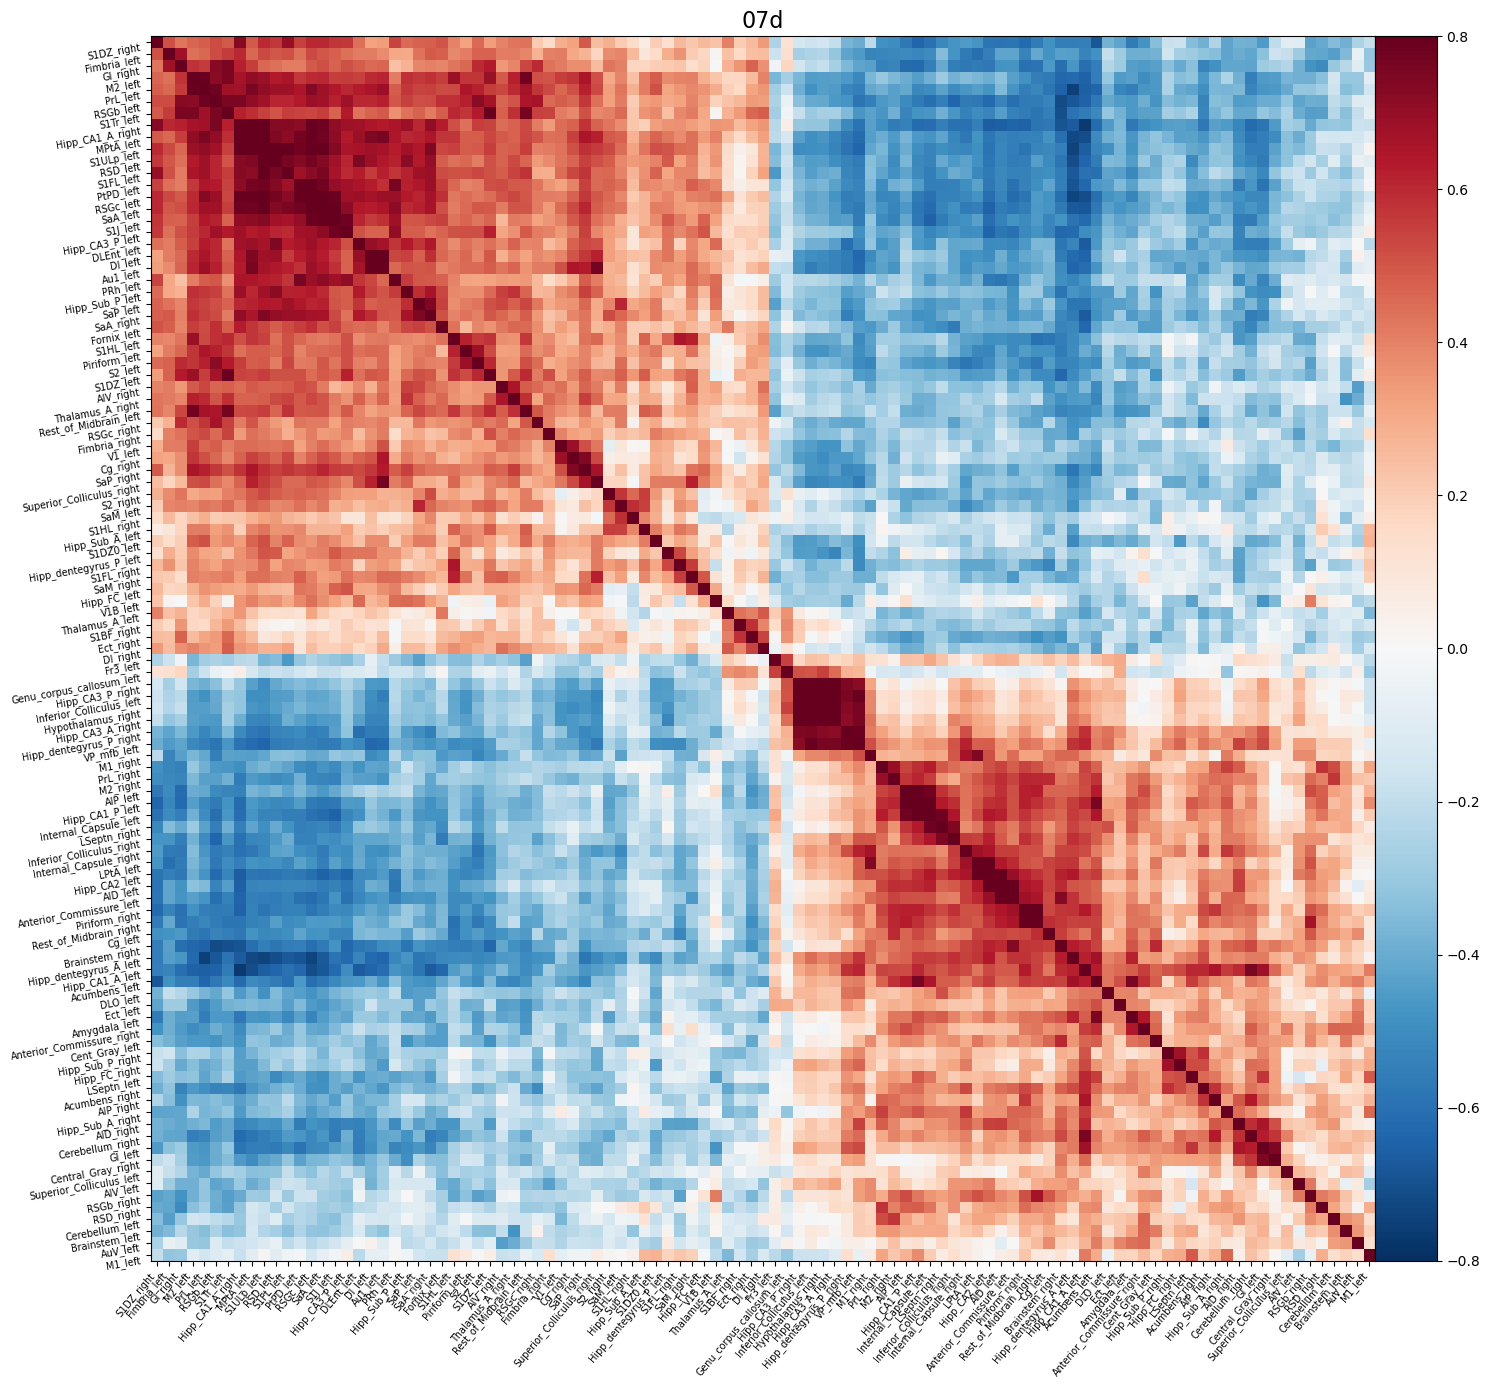

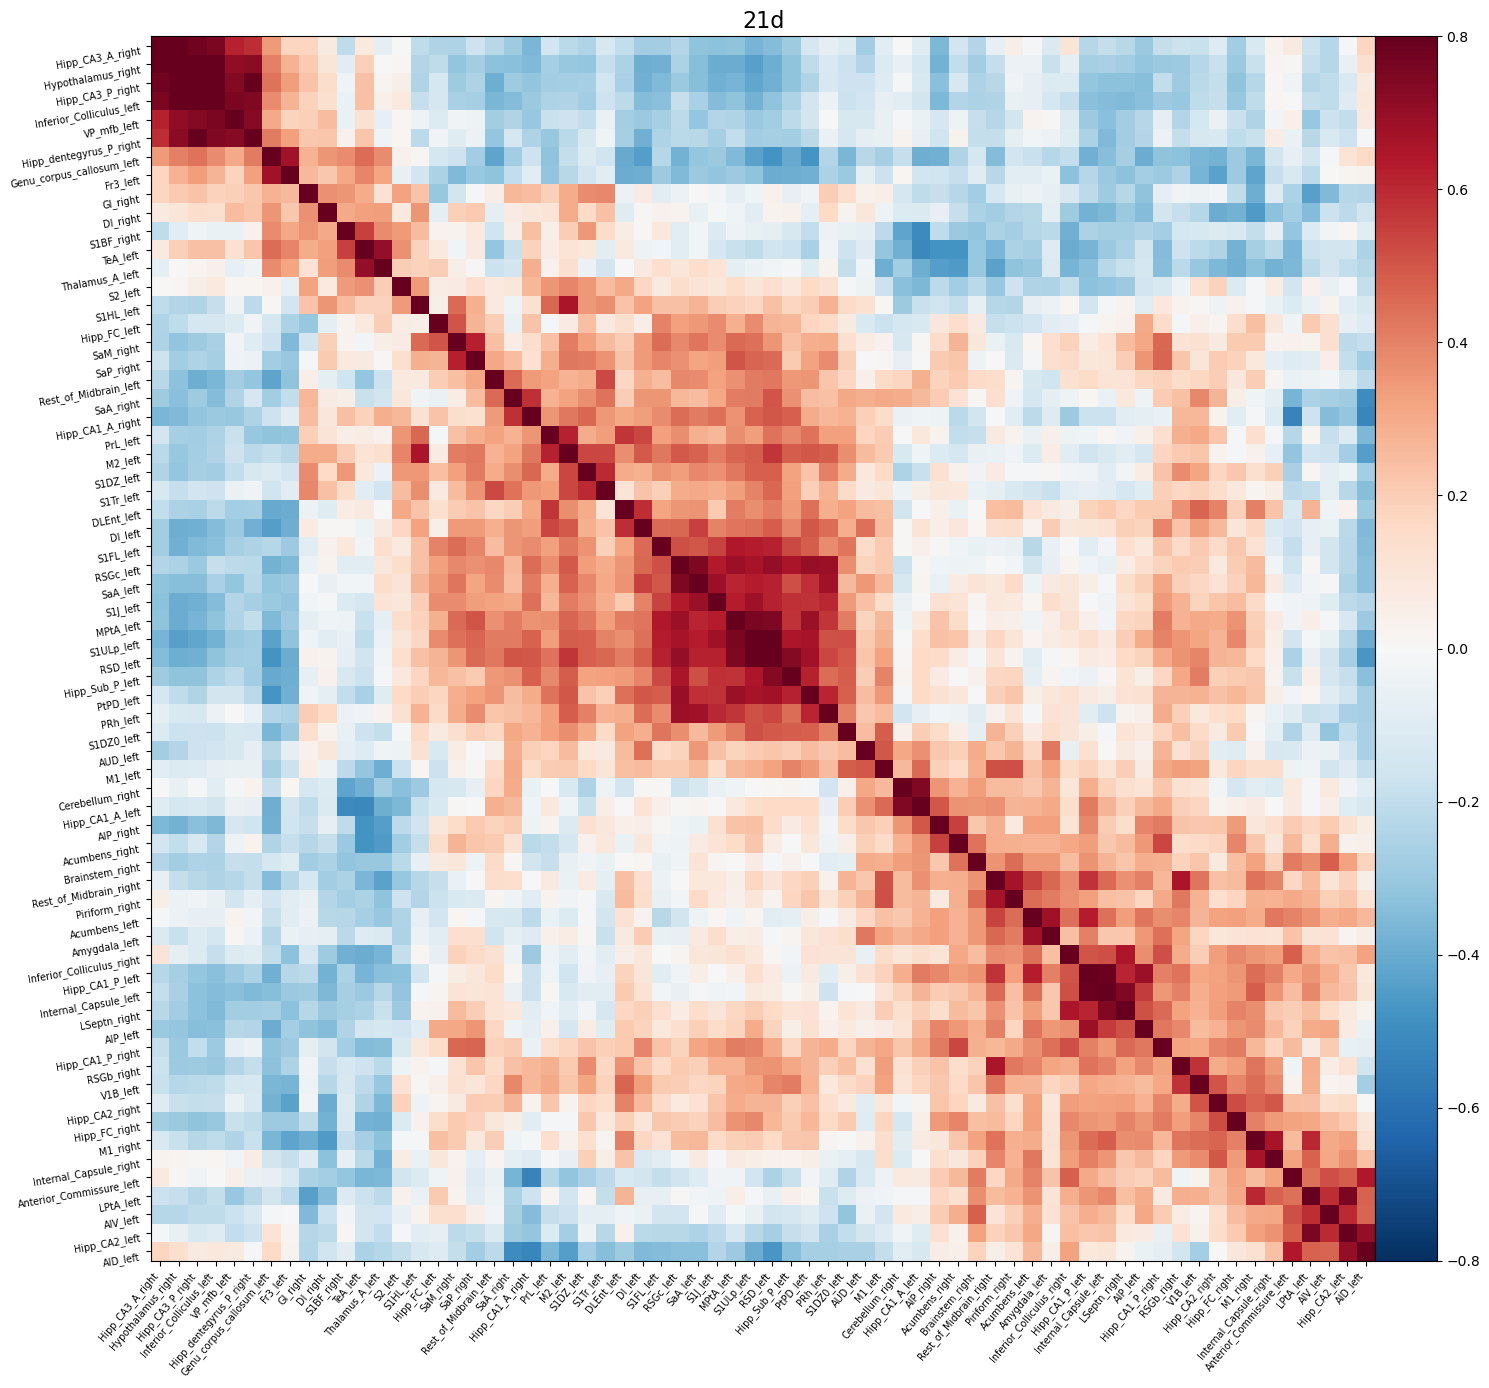

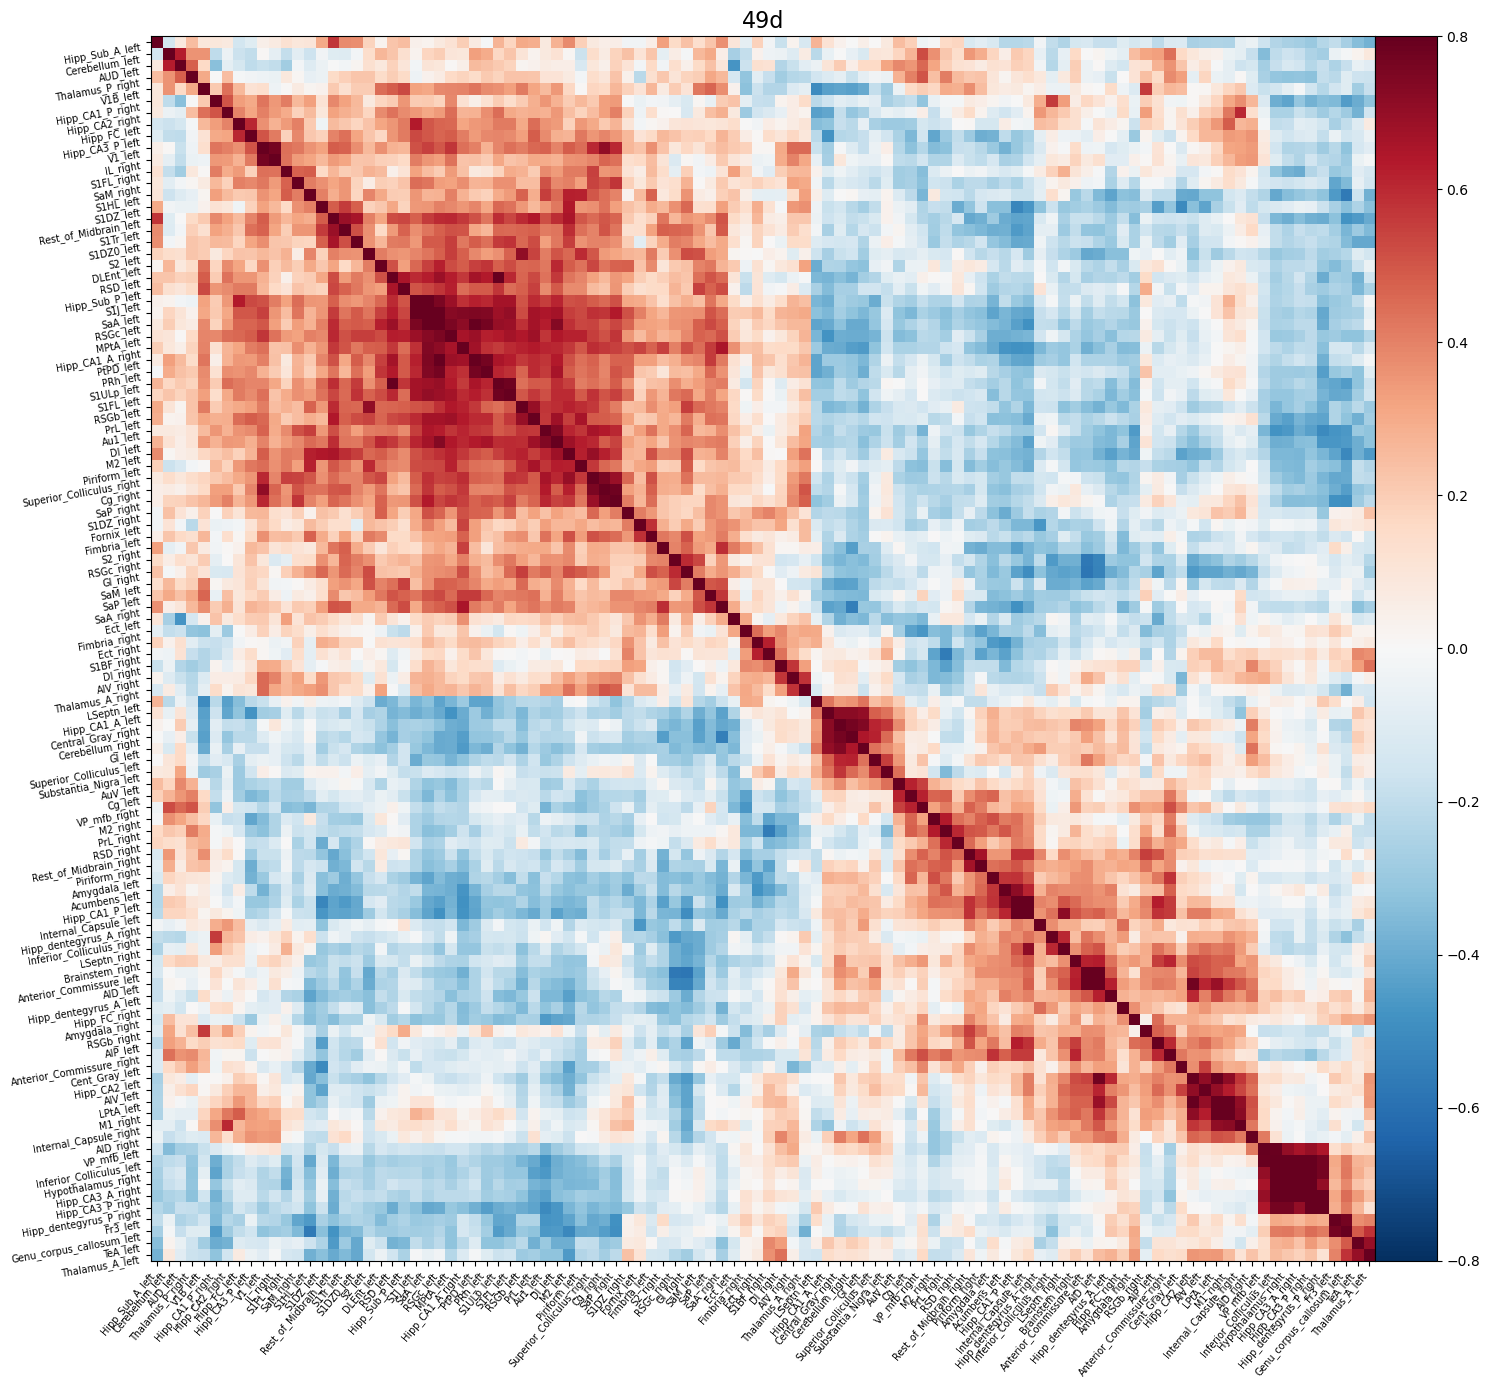

In [8]:
from nilearn.connectome import ConnectivityMeasure
from nilearn import plotting

correlation_measure = ConnectivityMeasure(kind='correlation')

ts_dict = {'07d':[seed_ts_SHM_07d, seed_ts_CCI_07d],
           '21d':[seed_ts_SHM_21d, seed_ts_CCI_21d],
           '49d':[seed_ts_SHM_49d, seed_ts_CCI_49d]}

corr_dict = {}

for day in ts_dict:    
    correlation_matrix_SHM = correlation_measure.fit_transform([ts_dict[day][0].T])[0]
    correlation_matrix_CCI = correlation_measure.fit_transform([ts_dict[day][1].T])[0]
    
    corr_dict[day] = [correlation_matrix_SHM, correlation_matrix_CCI]

    # Reduce matrix size, only for visualization purposes
    mat_mask = np.where(np.std(correlation_matrix_CCI, axis=1) > 0.2)[0]
    print(mat_mask)
    c = correlation_matrix_CCI[mat_mask][:, mat_mask]
    print(c.shape)
    # print(correlation_matrix_CCI.shape)

    # Create corresponding region names
    regions_list = labels
    #regions_list = ['%s_%s' % (h, r.decode()) for h in ['L', 'R'] for r in labels]
    masked_regions = [regions_list[i] for i in mat_mask]

    corr_plot = plotting.plot_matrix(c, title=day, figure=(15, 15), labels=masked_regions,
                                     vmax=0.8, vmin=-0.8, reorder=True)

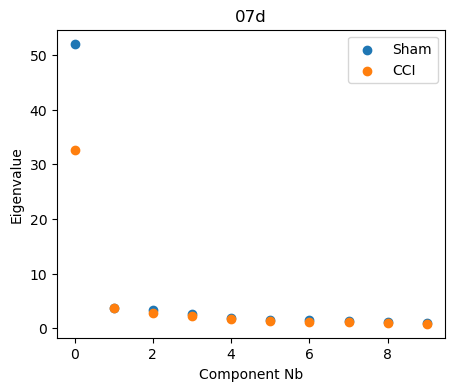

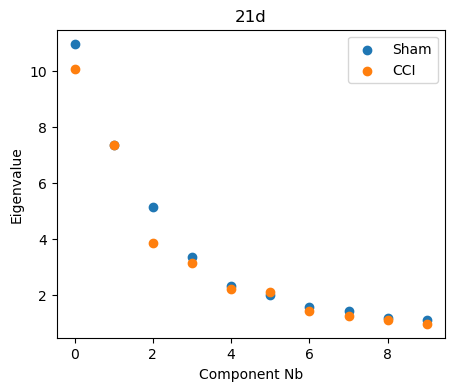

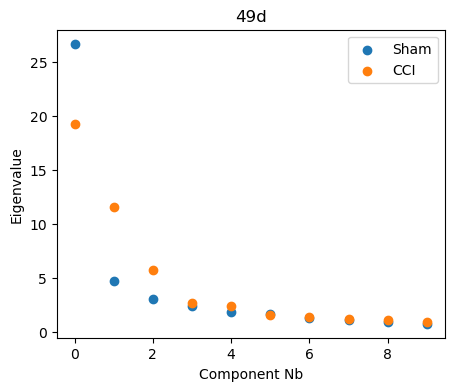

In [9]:
from brainspace.gradient import GradientMaps
from brainspace.datasets import load_fsa5
from brainspace.plotting import plot_hemispheres
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt

gm_dict = {}

for day in corr_dict:
    gm_SHM = GradientMaps(n_components=10, kernel='pearson', approach='dm', random_state=0)
    gm_SHM.fit(corr_dict[day][0])
    # print(gm_SHM)

    gm_CCI = GradientMaps(n_components=10, kernel='pearson', approach='dm', random_state=0)
    gm_CCI.fit(corr_dict[day][1])
    # print(gm_CCI)
    
    gm_dict[day] = [gm_SHM, gm_CCI]
    
    grad_SHM = [None] * gm_SHM.gradients_.T.shape[0]
    grad_CCI = [None] * gm_CCI.gradients_.T.shape[0]
    for i, g in enumerate(gm_SHM.gradients_.T):
        grad_SHM[i] = map_to_labels(g, labels, fill=np.nan)
    for i, g in enumerate(gm_CCI.gradients_.T):
        #print(g.shape) #400 which is the shape of the gradient
        grad_CCI[i] = map_to_labels(g, labels, fill=np.nan)
        #print(grad[i].shape) #64984 (same as labels)
    

    # print(gm_CCI.gradients_[:, 0].shape)


    fig, ax = plt.subplots(1, figsize=(5, 4))
    ax.scatter(range(gm_SHM.lambdas_.size), gm_SHM.lambdas_, label="Sham")
    ax.scatter(range(gm_CCI.lambdas_.size), gm_CCI.lambdas_, label="CCI")
    ax.set_title(day)
    ax.set_xlabel('Component Nb')
    ax.set_ylabel('Eigenvalue')
    ax.legend()

    #print(grad_CCI)

In [10]:
print(gm_dict)

{'07d': [GradientMaps(kernel='pearson', random_state=0), GradientMaps(kernel='pearson', random_state=0)], '21d': [GradientMaps(kernel='pearson', random_state=0), GradientMaps(kernel='pearson', random_state=0)], '49d': [GradientMaps(kernel='pearson', random_state=0), GradientMaps(kernel='pearson', random_state=0)]}


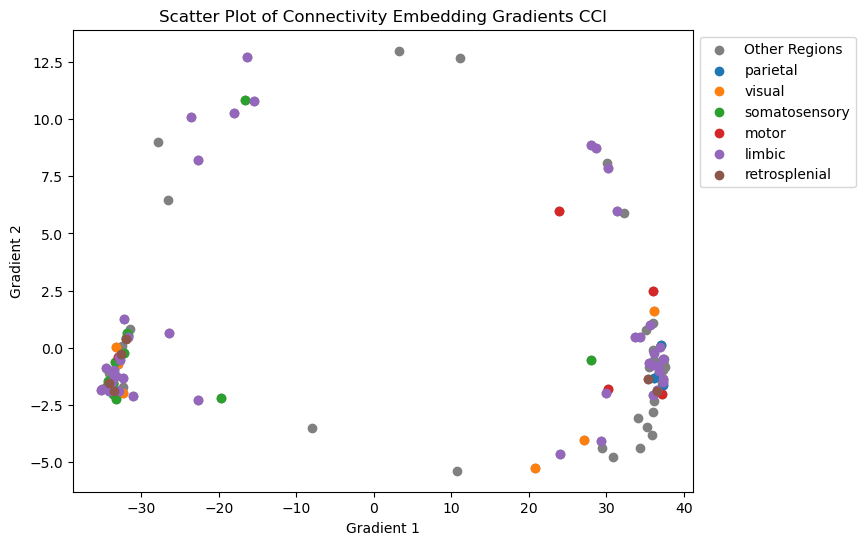

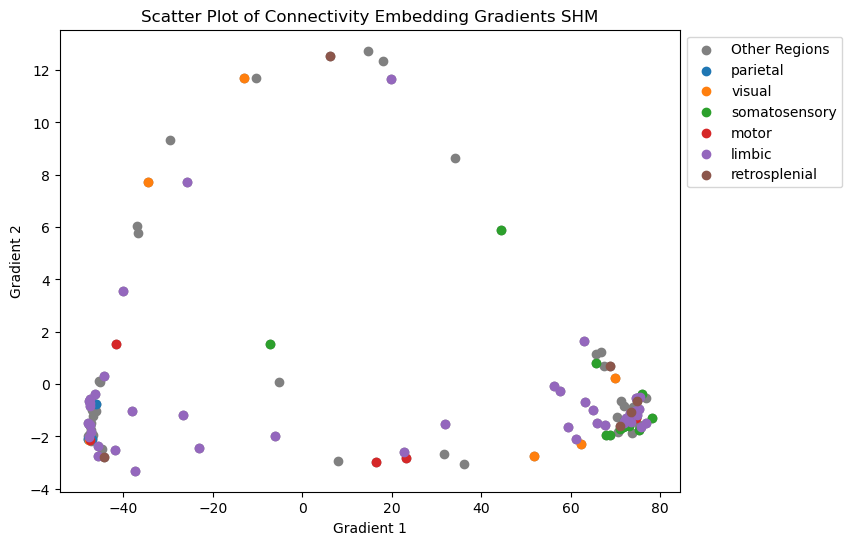

In [15]:
# gradient figures
# we'll focus on day 7 first
gradient1CCI_07d = gm_dict['07d'][1].gradients_[:, 0] # extract 1st component
gradient2CCI_07d = gm_dict['07d'][1].gradients_[:, 1] # extract 2nd component

gradient1SHM_07d = gm_dict['07d'][0].gradients_[:, 0] # extract 1st component
gradient2SHM_07d = gm_dict['07d'][0].gradients_[:, 1] # extract 2nd component

# yeo_categories = {
#     'visual': [4, 67, 68, 69, 70, 75],
#     'somatomotor': [7, 8, 9, 39, 40, 50, 51, 52, 53, 54, 55, 56, 57, 58, 104, 105, 112, 113, 114, 115, 116, 117],
#     #'dorsal attention': [],
#     #'ventral attention': [],
#     'limbic': [5, 13, 18, 19, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 76, 81, 85, 86, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98],
#     'frontoparietal': [34, 44, 100, 107],
#     'default mode': [15, 47, 48, 49, 83, 109, 110, 111]
# }

white_categories = {
    'parietal': [3, 37, 45, 74],
    'visual':[4, 67, 68, 69, 70, 75],
    'somatosensory': [50, 51, 52, 53, 54, 55, 56, 57, 58, 112, 113, 114, 115, 116, 117],
    'motor': [20, 39, 40, 104, 105],
    'limbic': [5, 13, 14, 15, 16, 17, 18, 19, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 38, 43, 44, 65, 66, 76, 81, 82, 83, 84, 85, 86, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 103, 107, 122, 123],
    'retrosplenial': [47, 48, 49, 109, 110, 111]
}

plt.figure(figsize=(8, 6))
plt.scatter(gradient1CCI_07d, gradient2CCI_07d, c='gray', label='Other Regions')

for category, indices in white_categories.items():
    adjusted_indices = np.array(indices) - 1
    plt.scatter(gradient1CCI_07d[adjusted_indices], gradient2CCI_07d[adjusted_indices], label=category)
plt.xlabel('Gradient 1')
plt.ylabel('Gradient 2')
plt.title('Scatter Plot of Connectivity Embedding Gradients CCI')
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')

plt.figure(figsize=(8, 6))
plt.scatter(gradient1SHM_07d, gradient2SHM_07d, c='gray', label='Other Regions')

for category, indices in white_categories.items():
    adjusted_indices = np.array(indices) - 1
    plt.scatter(gradient1SHM_07d[adjusted_indices], gradient2SHM_07d[adjusted_indices], label=category)
plt.xlabel('Gradient 1')
plt.ylabel('Gradient 2')
plt.title('Scatter Plot of Connectivity Embedding Gradients SHM')
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')

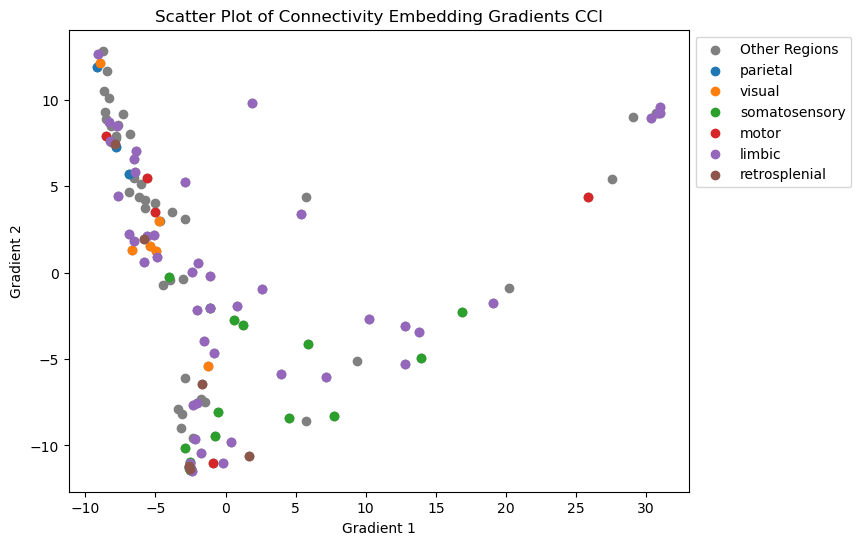

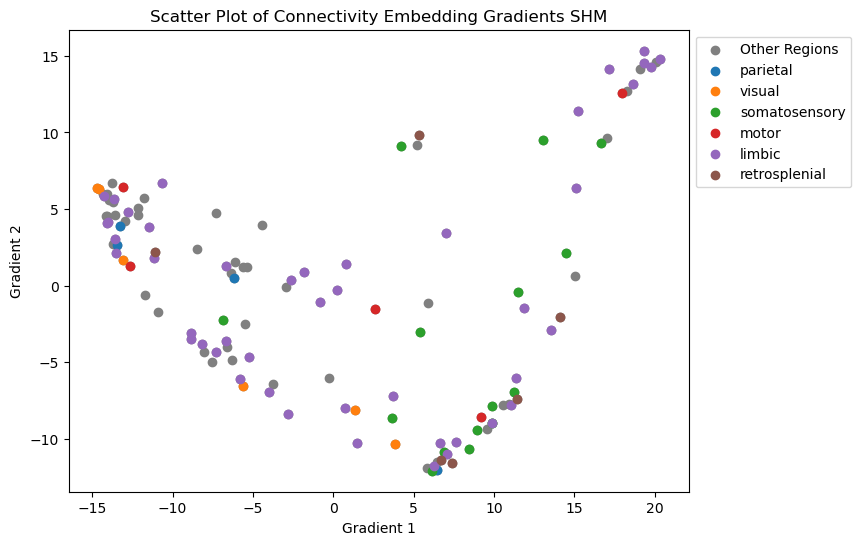

In [25]:
# day 21
gradient1CCI_21d = gm_dict['21d'][1].gradients_[:, 0] # extract 1st component
gradient2CCI_21d = gm_dict['21d'][1].gradients_[:, 1] # extract 2nd component

gradient1SHM_21d = gm_dict['21d'][0].gradients_[:, 0] # extract 1st component
gradient2SHM_21d = gm_dict['21d'][0].gradients_[:, 1] # extract 2nd component

plt.figure(figsize=(8, 6))
plt.scatter(gradient1CCI_21d, gradient2CCI_21d, c='gray', label='Other Regions')

for category, indices in white_categories.items():
    adjusted_indices = np.array(indices) - 1
    plt.scatter(gradient1CCI_21d[adjusted_indices], gradient2CCI_21d[adjusted_indices], label=category)
plt.xlabel('Gradient 1')
plt.ylabel('Gradient 2')
plt.title('Scatter Plot of Connectivity Embedding Gradients CCI')
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')

plt.figure(figsize=(8, 6))
plt.scatter(gradient1SHM_21d, gradient2SHM_21d, c='gray', label='Other Regions')

for category, indices in white_categories.items():
    adjusted_indices = np.array(indices) - 1
    plt.scatter(gradient1SHM_21d[adjusted_indices], gradient2SHM_21d[adjusted_indices], label=category)
plt.xlabel('Gradient 1')
plt.ylabel('Gradient 2')
plt.title('Scatter Plot of Connectivity Embedding Gradients SHM')
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')

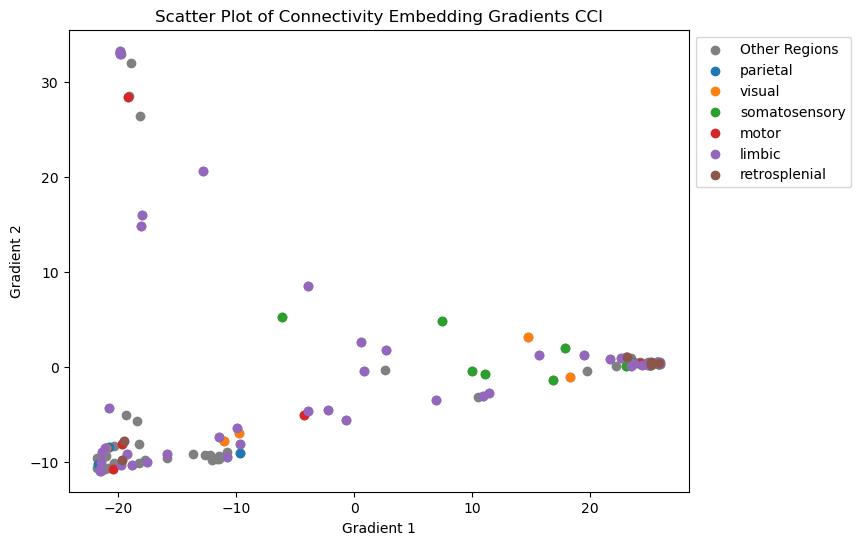

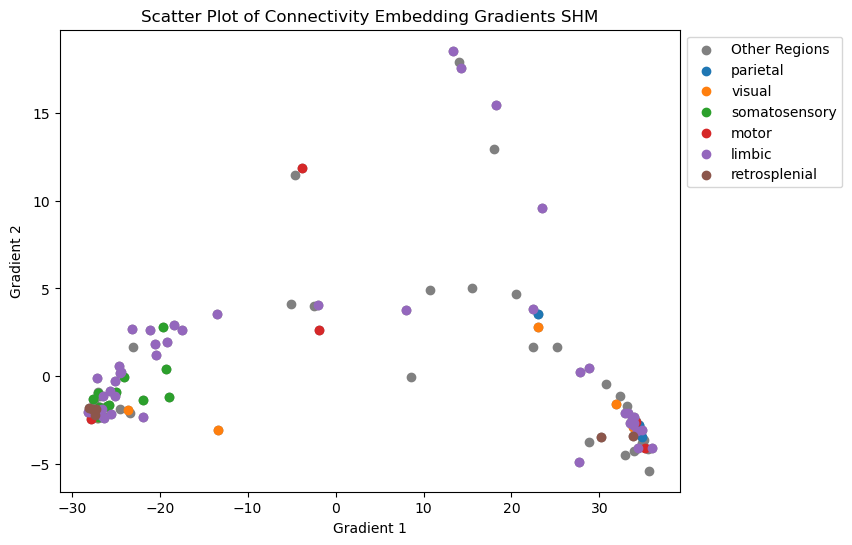

In [26]:
# day 49
gradient1CCI_49d = gm_dict['49d'][1].gradients_[:, 0] # extract 1st component
gradient2CCI_49d = gm_dict['49d'][1].gradients_[:, 1] # extract 2nd component

gradient1SHM_49d = gm_dict['49d'][0].gradients_[:, 0] # extract 1st component
gradient2SHM_49d = gm_dict['49d'][0].gradients_[:, 1] # extract 2nd component

plt.figure(figsize=(8, 6))
plt.scatter(gradient1CCI_49d, gradient2CCI_49d, c='gray', label='Other Regions')

for category, indices in white_categories.items():
    adjusted_indices = np.array(indices) - 1
    plt.scatter(gradient1CCI_49d[adjusted_indices], gradient2CCI_49d[adjusted_indices], label=category)
plt.xlabel('Gradient 1')
plt.ylabel('Gradient 2')
plt.title('Scatter Plot of Connectivity Embedding Gradients CCI')
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')

plt.figure(figsize=(8, 6))
plt.scatter(gradient1SHM_49d, gradient2SHM_49d, c='gray', label='Other Regions')

for category, indices in white_categories.items():
    adjusted_indices = np.array(indices) - 1
    plt.scatter(gradient1SHM_49d[adjusted_indices], gradient2SHM_49d[adjusted_indices], label=category)
plt.xlabel('Gradient 1')
plt.ylabel('Gradient 2')
plt.title('Scatter Plot of Connectivity Embedding Gradients SHM')
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')

In [19]:
parc = np.array(nib.load('01_study_specific_atlas_relabel.nii').get_fdata().flatten())
print(parc)

[0. 0. 0. ... 0. 0. 0.]
